<a href="https://colab.research.google.com/github/deepakraolive/Social-Media-Data-Analysis/blob/main/SocialMedia_Analysis_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Youtube Content Data Analysis

Welcome! This notebook is designed for Google Colab. It will show you how to securely load a massive dataset from Google Drive and perform basic Data Science tasks (EDA, Visualizations, Hypothesis Testing, and Linear Regression).

## Step 1: Connect to Google Drive
Run this cell to mount your Google Drive. A popup will ask for permission to access your files, just click 'Allow'.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Load the Data Safely (Sampling)
Instead of loading the entire massive file (which might crash Colab), we will load a sample of 10,000 rows. This is lightning fast and perfect for beginners!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Change this path if your file is inside a specific folder in your Drive
file_path = '/content/drive/MyDrive/Data Science/GobalTrendingYtData.csv'

# Load only the first 10,000 rows
df = pd.read_csv(file_path, nrows=10000)

print("Data loaded successfully! Here are the first 5 rows:")
df.head()

Data loaded successfully! Here are the first 5 rows:


,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,...,channel_description,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description
0,bB3-CUMERIU,2024-10-11T00:00:06Z,2024.10.12,United Arab Emirates,UCNYi_zGmR519r5gYdOKLTjQ,JENNIE - Mantra (Official Music Video),Official music video for “Mantra” by JENNIE ou...,https://i.ytimg.com/vi/bB3-CUMERIU/default.jpg,Music,"JENNIE,Mantra,제니,Jennie Mantra,Jennie from Bla...",...,NaN,@jennierubyjane,2021-01-13T06:19:55.86689Z,NaN,464615150.0,11600000.0,False,43.0,JENNIE,NaN
1,5ObJt_71AYc,2024-10-11T02:59:21Z,2024.10.12,United Arab Emirates,UCzU8-lZlRfkV3nj0RzAZdrQ,CHILE vs. BRASIL [1-2] | RESUMEN | ELIMINATORI...,#Chile #Brasil #eliminatoriassudamericanas #Cr...,https://i.ytimg.com/vi/5ObJt_71AYc/default.jpg,Sports,"fútbol,pelota,gol,copa,libertadores,sudamerica...",...,Canal Oficial de la Confederación Sudamericana...,@conmebol,2014-02-19T20:24:31Z,NaN,399046746.0,1610000.0,False,4637.0,CONMEBOL,Canal Oficial de la Confederación Sudamericana...
2,zfb0whgBBA8,2024-10-11T11:07:25Z,2024.10.12,United Arab Emirates,UCgGYPnVJytkr6sVNLQ-l0zQ,تحدي الحقيبة مع ابو عبير 🔥 | سلسلتنا #2,"1,375,547 مشترك❤️\n\nـــــــــــــــــــــــــ...",https://i.ytimg.com/vi/zfb0whgBBA8/default.jpg,Gaming,"تشكيله,فيفا,فيفا20,التمت,درافت,زلاتان,ام,جي,مل...",...,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚,@mrlle99,2012-08-01T16:24:26Z,Saudi Arabia,114331110.0,1380000.0,False,314.0,LLE عبدالاله,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚
3,SJfoPdeOPCQ,2024-10-11T00:10:10Z,2024.10.12,United Arab Emirates,UCzU8-lZlRfkV3nj0RzAZdrQ,VENEZUELA vs. ARGENTINA [1-1] | RESUMEN | ELIM...,#Venezuela #Argentina #eliminatoriassudamerica...,https://i.ytimg.com/vi/SJfoPdeOPCQ/default.jpg,Sports,"fútbol,pelota,gol,copa,libertadores,sudamerica...",...,Canal Oficial de la Confederación Sudamericana...,@conmebol,2014-02-19T20:24:31Z,NaN,399046746.0,1610000.0,False,4637.0,CONMEBOL,Canal Oficial de la Confederación Sudamericana...
4,UVb6QOKy0bI,2024-10-09T12:30:27Z,2024.10.12,United Arab Emirates,UCOzubmwpVZI7gD0Jf7Bk3Aw,Bougainvillea Trailer | October 17 | Jyothirma...,Presenting The Official Trailer of Bougainvill...,https://i.ytimg.com/vi/UVb6QOKy0bI/default.jpg,Film & Animation,NaN,...,Official YouTube Channel Of Amal Neerad Produc...,@amalneeradproductions5264,2017-05-31T14:31:01Z,NaN,19991522.0,40600.0,False,56.0,Amal Neerad Productions,Official YouTube Channel Of Amal Neerad Produc...


## Step 3: Exploratory Data Analysis (EDA)
Let's get to know our dataset by checking the data types, missing values, and getting a statistical summary.

In [ ]:
print("\n--- Data Information ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Quick Math Summary ---")
print(df.describe())


--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   video_id                         10000 non-null  object 
 1   video_published_at               10000 non-null  object 
 2   video_trending__date             10000 non-null  object 
 3   video_trending_country           10000 non-null  object 
 4   channel_id                       10000 non-null  object 
 5   video_title                      10000 non-null  object 
 6   video_description                8811 non-null   object 
 7   video_default_thumbnail          10000 non-null  object 
 8   video_category_id                9994 non-null   object 
 9   video_tags                       7320 non-null   object 
 10  video_duration                   10000 non-null  object 
 11  video_dimension                  10000 non-null  object

## Step 4: Visualizations
Let's draw some pictures to find visual trends in our data.

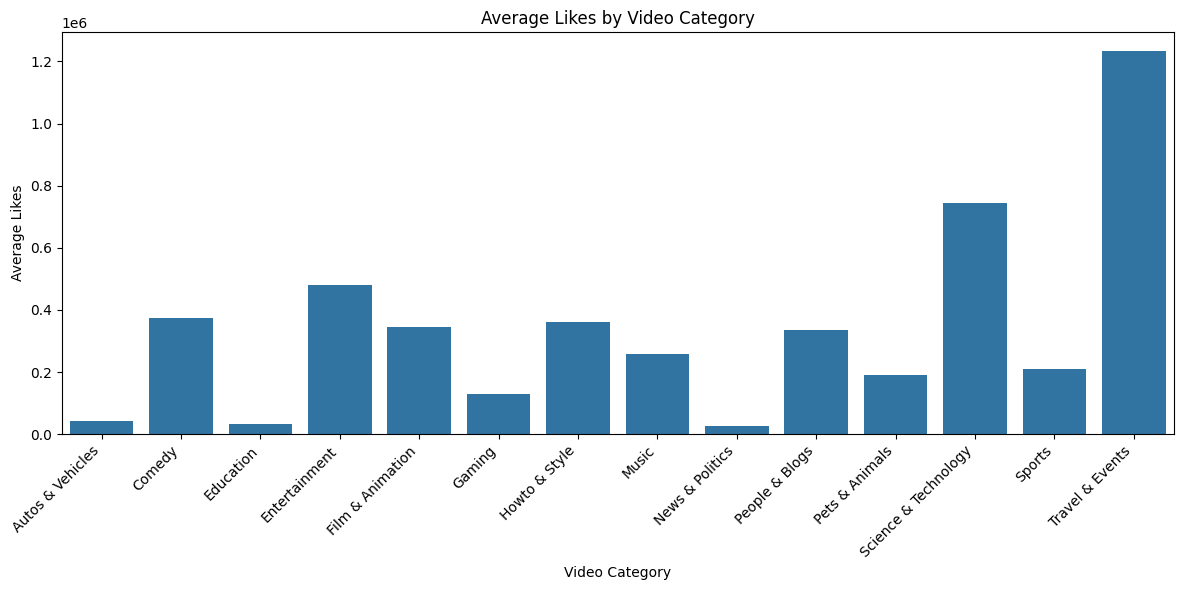

In [ ]:
# =========================
# A. Bar Chart: Average Likes by Video Category
# =========================
avg_likes = df.groupby('video_category_id')['video_like_count'].mean().reset_index()

plt.figure(figsize=(12,6))  # increase size
sns.barplot(data=avg_likes, x='video_category_id', y='video_like_count')

plt.title('Average Likes by Video Category')
plt.xlabel('Video Category')
plt.ylabel('Average Likes')

plt.xticks(rotation=45, ha='right')  # rotate labels
plt.tight_layout()  # auto adjust spacing

plt.show()


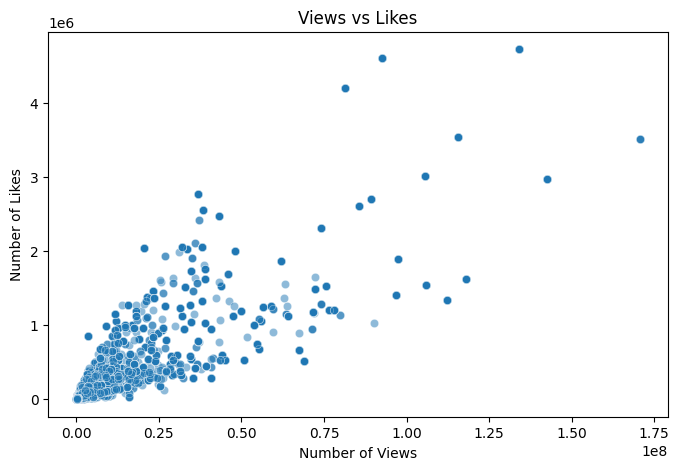

In [ ]:

# =========================
# B. Scatter Plot: Views vs Likes
# =========================
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='video_view_count', y='video_like_count', alpha=0.5)
plt.title('Views vs Likes')
plt.xlabel('Number of Views')
plt.ylabel('Number of Likes')
plt.show()




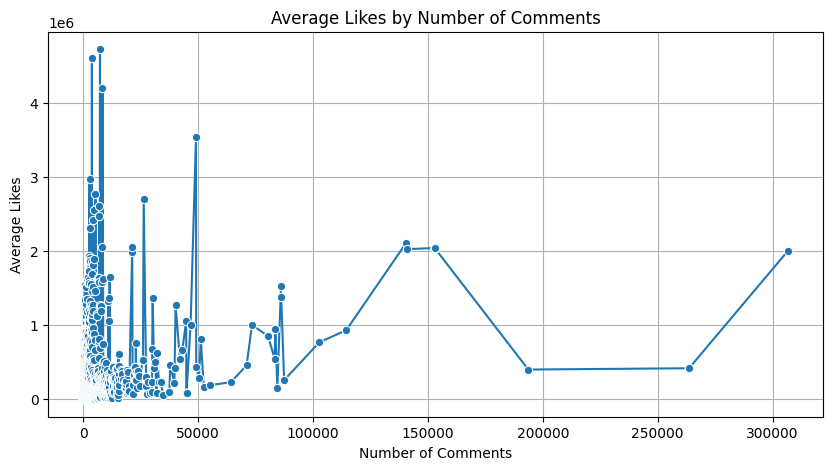

In [ ]:
# =========================
# C. Line Chart: Comments vs Average Likes
# =========================
avg_comment_likes = df.groupby('video_comment_count')['video_like_count'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_comment_likes, x='video_comment_count', y='video_like_count', marker='o')
plt.title('Average Likes by Number of Comments')
plt.xlabel('Number of Comments')
plt.ylabel('Average Likes')
plt.grid(True)
plt.show()

## Step 5: Hypothesis Testing
We use a T-Test to see if the difference in likes between 'video' and 'image' posts is mathematically real, or just random luck.

In [ ]:
# Select two categories automatically
categories = df['video_category_id'].unique()

cat1 = df[df['video_category_id'] == categories[0]]['video_like_count']
cat2 = df[df['video_category_id'] == categories[1]]['video_like_count']

# ADD THIS (IMPORTANT FIX)
cat1 = cat1.dropna()
cat2 = cat2.dropna()

# Check if enough data exists
if len(cat1) > 1 and len(cat2) > 1:

    # Perform T-test
    t_stat, p_value = stats.ttest_ind(cat1, cat2, equal_var=False)

    print("P-value:", p_value)

    if p_value < 0.05:
        print("Conclusion: The difference is REAL! Different categories get different likes.")
    else:
        print("Conclusion: The difference is not significant. Categories perform similarly.")

else:
    print("Not enough data for T-test. Please choose different categories.")

P-value: 0.027257217539103797
Conclusion: The difference is REAL! Different categories get different likes.


## Step 6: Simple Linear Regression
We draw a 'line of best fit' to predict how many likes a post will get based purely on the number of followers.

In [ ]:
# Clean data
clean_df = df.dropna(subset=['video_view_count', 'video_like_count'])

# Independent variable (X)
X = clean_df['video_view_count']
X = sm.add_constant(X)

# Dependent variable (y)
y = clean_df['video_like_count']

# Build model
model = sm.OLS(y, X).fit()

# Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       video_like_count   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                 2.500e+04
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:54:45   Log-Likelihood:            -1.3885e+05
No. Observations:                9827   AIC:                         2.777e+05
Df Residuals:                    9825   BIC:                         2.777e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             6.041e+04   3721.847  

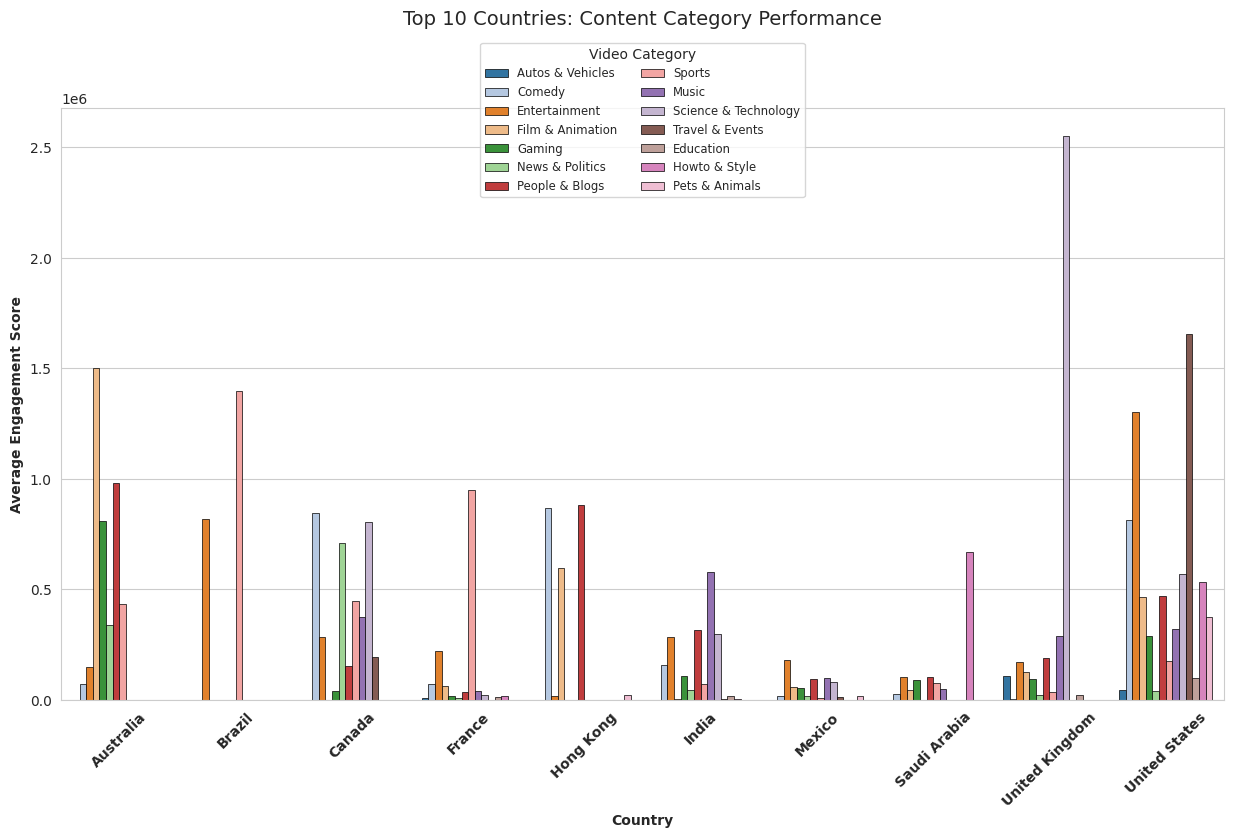

In [ ]:
# Create engagement score
df['engagement_score'] = (
    df['video_like_count'] +
    2 * df['video_comment_count']
)

# Top 10 countries
top_countries = (
    df.groupby('channel_country')['engagement_score']
    .sum()
    .nlargest(10)
    .index
)

# Filter data
df_top = df[df['channel_country'].isin(top_countries)]

# Grouping
result = (
    df_top.groupby(['channel_country', 'video_category_id'])['engagement_score']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(15, 8))

# Using 'tab20' for high-contrast dark colors
sns.barplot(
    data=result,
    x='channel_country',
    y='engagement_score',
    hue='video_category_id',
    palette='tab20',
    edgecolor='black',
    linewidth=0.5
)

plt.xticks(rotation=45, fontweight='bold')
plt.ylabel("Average Engagement Score", fontweight='bold')
plt.xlabel("Country", fontweight='bold')

# --- THE FIX ---
# 1. Lowered the anchor slightly (from 1.15 to 1.12)
# 2. Added a Title with a larger pad
plt.title("Top 10 Countries: Content Category Performance", fontsize=14, pad=60)

# 3. Legend placement
plt.legend(
    title='Video Category',
    bbox_to_anchor=(0.5, 1.12),
    loc='upper center',
    ncol=2,
    frameon=True,
    fontsize='small'
)

# 4. Manually adjust the top margin so the legend doesn't get cut off
plt.subplots_adjust(top=0.85)

plt.show()